In [2]:
import numpy as np 
import pickle 
import pandas as pd 
from sklearn.metrics import confusion_matrix
import re
%matplotlib inline 
import matplotlib.pyplot as plt 
import seaborn as sns
import yaml 
from pathlib import Path
import matplotlib
# matplotlib.rcParams.update({'font.size': 26})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import sys
sys.path.append('../')

In [5]:
path_to_esc_results = Path("eval_jsin_results")

all_model_results = list(path_to_esc_results.rglob("*linear_eval_jsin.pkl"))
# all_model_results

In [65]:

results_dfs = []
for result_file in all_model_results:
    result_dict = pd.read_pickle(result_file)
    result_dict['model'] = result_file.stem.split("_linear_eval_jsin")[0]
    results_dfs.append(result_dict)
df = pd.DataFrame.from_dict(results_dfs)
df['mean_acc'] = df['mean_acc'].apply(lambda x: x.numpy())
df['sem_acc'] = df['sem_acc'].apply(lambda x: x.numpy())
df['std_acc'] = df['std_acc'].apply(lambda x: x.numpy())



/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


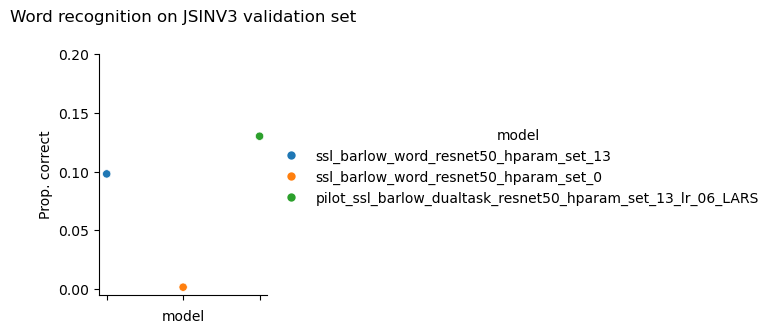

In [101]:

# fig, axs = plt.subplots(figsize=(2,4))
g = sns.relplot(data=df, x='model', hue='model', y='mean_acc', height=3, aspect=1,  markers='.')
g.set_xticklabels('', rotation=90)
axs = g.axes[0][0]
axs.set_yticks(np.linspace(0,.2, 5))
axs.set_ylabel('Prop. correct')
axs.set_title('Word recognition on JSINV3 validation set', y=1.1);
# plt.tight_layout()

array([0. , 0.1, 0.2])